# STAT 426B: Homework 3
# Multivariate Time Series Forecasting with RNNs

In this notebook, we predict **PM2.5** air pollution levels using the Beijing Multi-Site Air Quality Dataset (Aotizhongxin station). We implement and compare:
- Persistence and Linear baselines
- Vanilla RNN, LSTM, and GRU architectures

**Dataset**: [Beijing Multi-Site Air Quality Data](https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data)  
**Station**: Aotizhongxin  
**Task**: Given the past T=24 hours of multivariate features, predict PM2.5 at time t+1.

---
## Part (a): Preprocessing & Baselines [30 Points]

### Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import time
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device selection
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


### 1. Load Data

In [ ]:
# Load the Beijing Air Quality Dataset (Aotizhongxin station)
data_path = "PRSA_Data_Aotizhongxin_20130301-20170228.csv"
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['year'].min()}-{df['month'].min():02d} to {df['year'].max()}-{df['month'].max():02d}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (35064, 18)
Date range: 2013-01 to 2017-12

Columns: ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']

First few rows:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64


### 2. Imputation

We use **linear interpolation** for numeric columns and **mode filling** for the categorical wind direction column. Linear interpolation is appropriate here because the data is hourly and adjacent hours tend to have similar values.

In [4]:
df_processed = df.copy()

# Linear interpolation for numeric columns
numeric_columns = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df_processed[numeric_columns] = df_processed[numeric_columns].interpolate(method='linear', limit_direction='both')

# Fill missing wind directions with mode
df_processed['wd'] = df_processed['wd'].fillna(df_processed['wd'].mode()[0])

print("After imputation - Missing values:")
print(df_processed[numeric_columns + ['wd']].isnull().sum())

After imputation - Missing values:
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
wd       0
dtype: int64


### 3. Feature Engineering: Wind Direction

Wind direction is **cyclical** data: North (0 deg) and NNW (337.5 deg) are adjacent, but integer encoding would place them far apart. We convert wind direction strings to angles, then encode as sin/cos to preserve the circular relationship.

In [5]:
# Map wind direction strings to degrees
wind_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}

# Convert to radians, then sin/cos
df_processed['wd_rad'] = df_processed['wd'].map(wind_map) * np.pi / 180
df_processed['wd_sin'] = np.sin(df_processed['wd_rad'])
df_processed['wd_cos'] = np.cos(df_processed['wd_rad'])

# Select features for modeling
feature_columns = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                   'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
                   'wd_sin', 'wd_cos']
data = df_processed[feature_columns].values

# Final NaN check
if np.any(np.isnan(data)):
    print("Warning: Remaining NaN values, filling with 0")
    data = np.nan_to_num(data, nan=0.0)

print(f"Feature matrix shape: {data.shape}")
print(f"Features ({len(feature_columns)}): {feature_columns}")

Feature matrix shape: (35064, 13)
Features (13): ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'wd_sin', 'wd_cos']


### 4. Train/Validation/Test Split & Normalization

For time series, we use a **chronological split** (no shuffling) to prevent future data from leaking into training. The scaler is fitted **only on the training data** and then applied to validation and test sets.

In [6]:
n = len(data)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

print(f"Train: {train_data.shape} (rows 0 to {train_end-1})")
print(f"Val:   {val_data.shape} (rows {train_end} to {val_end-1})")
print(f"Test:  {test_data.shape} (rows {val_end} to {n-1})")

# Fit scaler ONLY on training data (prevents data leakage)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

print(f"\nScaler fitted on training data only.")
print(f"Train mean (first 3 features): {train_scaled.mean(axis=0)[:3].round(6)}")
print(f"Train std  (first 3 features): {train_scaled.std(axis=0)[:3].round(6)}")

Train: (28051, 13) (rows 0 to 28050)
Val:   (3506, 13) (rows 28051 to 31556)
Test:  (3507, 13) (rows 31557 to 35063)

Scaler fitted on training data only.
Train mean (first 3 features): [0. 0. 0.]
Train std  (first 3 features): [1. 1. 1.]


### 5. Sliding Window Dataset (T=24)

We create input-output pairs using a sliding window:
- **Input (X)**: Past T=24 hours of ALL features &rarr; shape `(24, 13)`
- **Output (y)**: PM2.5 value at hour t+1 &rarr; scalar

In [7]:
def create_sliding_window_dataset(data, target_col_idx, window_size=24):
    """
    Create sliding window dataset for time series forecasting.
    
    Args:
        data: numpy array (n_timesteps, n_features), should be normalized
        target_col_idx: column index of the target variable (PM2.5)
        window_size: number of past timesteps to use (T=24)
    
    Returns:
        X: (n_samples, window_size, n_features)
        y: (n_samples,)
    """
    n_samples = len(data) - window_size
    n_features = data.shape[1]
    
    X = np.zeros((n_samples, window_size, n_features))
    y = np.zeros(n_samples)
    
    for i in range(n_samples):
        X[i] = data[i:i+window_size]
        y[i] = data[i+window_size, target_col_idx]
    
    return X, y

PM25_COL_IDX = 0  # PM2.5 is the first column
WINDOW_SIZE = 24

X_train, y_train = create_sliding_window_dataset(train_scaled, PM25_COL_IDX, WINDOW_SIZE)
X_val, y_val = create_sliding_window_dataset(val_scaled, PM25_COL_IDX, WINDOW_SIZE)
X_test, y_test = create_sliding_window_dataset(test_scaled, PM25_COL_IDX, WINDOW_SIZE)

print(f"Training set:   X={X_train.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test.shape}, y={y_test.shape}")
print(f"\nEach sample: {WINDOW_SIZE} hours x {X_train.shape[2]} features -> 1 PM2.5 value")

Training set:   X=(28027, 24, 13), y=(28027,)
Validation set: X=(3482, 24, 13), y=(3482,)
Test set:       X=(3483, 24, 13), y=(3483,)

Each sample: 24 hours x 13 features -> 1 PM2.5 value


### 6. Create PyTorch DataLoaders

In [8]:
batch_size = 64

# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Batch size: 64
Training batches: 438
Validation batches: 55
Test batches: 55


### 7. Metric Utilities

In [9]:
def calculate_metrics(y_true, y_pred, scaler=None, target_col_idx=0):
    """
    Calculate RMSE and MAE. Optionally inverse-transform to original scale.
    """
    if scaler is not None:
        n_features = scaler.scale_.shape[0]
        y_true_dummy = np.zeros((len(y_true), n_features))
        y_pred_dummy = np.zeros((len(y_pred), n_features))
        y_true_dummy[:, target_col_idx] = y_true
        y_pred_dummy[:, target_col_idx] = y_pred
        y_true = scaler.inverse_transform(y_true_dummy)[:, target_col_idx]
        y_pred = scaler.inverse_transform(y_pred_dummy)[:, target_col_idx]
    
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    return rmse, mae

### 8. Baseline 1: Persistence Model

The persistence model predicts $y_{t+1} = y_t$, i.e., the PM2.5 value at the next hour equals the current hour's value. This is the simplest baseline and reflects the strong autocorrelation in air quality data.

In [10]:
# Persistence: predict last known PM2.5 value in the window
y_pred_persist = X_test[:, -1, PM25_COL_IDX]

rmse_persist_norm, mae_persist_norm = calculate_metrics(y_test, y_pred_persist)
rmse_persist, mae_persist = calculate_metrics(y_test, y_pred_persist, scaler, PM25_COL_IDX)

print("Persistence Model (Test Set):")
print(f"  Normalized  - RMSE: {rmse_persist_norm:.4f}, MAE: {mae_persist_norm:.4f}")
print(f"  Original    - RMSE: {rmse_persist:.2f} ug/m3, MAE: {mae_persist:.2f} ug/m3")

Persistence Model (Test Set):
  Normalized  - RMSE: 0.2897, MAE: 0.1526
  Original    - RMSE: 23.61 ug/m3, MAE: 12.44 ug/m3


### 9. Baseline 2: Linear Regression

A simple linear regression takes the flattened 24-hour window (24 x 13 = 312 features) as input and predicts PM2.5 at t+1.

In [11]:
# Flatten windows for linear regression
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

lr_model = LinearRegression()
lr_model.fit(X_train_flat, y_train)

y_pred_linear = lr_model.predict(X_test_flat)

rmse_linear_norm, mae_linear_norm = calculate_metrics(y_test, y_pred_linear)
rmse_linear, mae_linear = calculate_metrics(y_test, y_pred_linear, scaler, PM25_COL_IDX)

print(f"Linear model input dimension: {X_train_flat.shape[1]} features")
print(f"\nLinear Regression (Test Set):")
print(f"  Normalized  - RMSE: {rmse_linear_norm:.4f}, MAE: {mae_linear_norm:.4f}")
print(f"  Original    - RMSE: {rmse_linear:.2f} ug/m3, MAE: {mae_linear:.2f} ug/m3")

Linear model input dimension: 312 features

Linear Regression (Test Set):
  Normalized  - RMSE: 0.2647, MAE: 0.1479
  Original    - RMSE: 21.58 ug/m3, MAE: 12.05 ug/m3


### Baseline Summary

In [12]:
print("=" * 55)
print("BASELINE RESULTS (Test Set, Original Scale)")
print("=" * 55)
print(f"{'Model':<20} {'RMSE (ug/m3)':>15} {'MAE (ug/m3)':>15}")
print("-" * 55)
print(f"{'Persistence':<20} {rmse_persist:>15.2f} {mae_persist:>15.2f}")
print(f"{'Linear Regression':<20} {rmse_linear:>15.2f} {mae_linear:>15.2f}")
print("=" * 55)

BASELINE RESULTS (Test Set, Original Scale)
Model                   RMSE (ug/m3)     MAE (ug/m3)
-------------------------------------------------------
Persistence                    23.61           12.44
Linear Regression              21.58           12.05


---
## Part (b): RNN, LSTM, and GRU Implementation [40 Points]

### Model Definitions

All three models follow the **Many-to-One** regression pattern:
1. Process the input sequence of T=24 timesteps through the recurrent layers
2. Extract the final hidden state as a summary of the sequence
3. Pass through a linear layer to predict a single PM2.5 value

In [13]:
class VanillaRNNForecaster(nn.Module):
    """Vanilla RNN for PM2.5 forecasting."""
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        prediction = self.fc(out[:, -1, :])
        return prediction.squeeze(-1)


class LSTMForecaster(nn.Module):
    """LSTM for PM2.5 forecasting."""
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        prediction = self.fc(out[:, -1, :])
        return prediction.squeeze(-1)


class GRUForecaster(nn.Module):
    """GRU for PM2.5 forecasting."""
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        prediction = self.fc(out[:, -1, :])
        return prediction.squeeze(-1)


print("Model classes defined: VanillaRNNForecaster, LSTMForecaster, GRUForecaster")

Model classes defined: VanillaRNNForecaster, LSTMForecaster, GRUForecaster


### Training Function with Early Stopping

In [14]:
def train_model(model, train_loader, val_loader, num_epochs=50, lr=0.001, patience=7):
    """
    Train a model with early stopping based on validation loss.
    
    Returns:
        history: dict with training/validation loss and RMSE per epoch
        avg_epoch_time: average training time per epoch (seconds)
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': [], 'train_rmse': [], 'val_rmse': []}
    
    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0
    epoch_times = []
    
    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        train_loss = 0.0
        train_preds, train_targets = [], []
        
        epoch_start = time.time()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * batch_X.size(0)
            train_preds.extend(predictions.detach().cpu().numpy())
            train_targets.extend(batch_y.cpu().numpy())
        
        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)
        
        train_loss /= len(train_loader.dataset)
        train_rmse = np.sqrt(mean_squared_error(train_targets, train_preds))
        
        # --- Validation ---
        model.eval()
        val_loss = 0.0
        val_preds, val_targets = [], []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                val_loss += loss.item() * batch_X.size(0)
                val_preds.extend(predictions.cpu().numpy())
                val_targets.extend(batch_y.cpu().numpy())
        
        val_loss /= len(val_loader.dataset)
        val_rmse = np.sqrt(mean_squared_error(val_targets, val_preds))
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_rmse'].append(train_rmse)
        history['val_rmse'].append(val_rmse)
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:2d}/{num_epochs}]  "
                  f"Train Loss: {train_loss:.6f}  RMSE: {train_rmse:.4f}  |  "
                  f"Val Loss: {val_loss:.6f}  RMSE: {val_rmse:.4f}  "
                  f"({epoch_time:.2f}s)")
        
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    avg_epoch_time = np.mean(epoch_times)
    print(f"\nBest validation loss: {best_val_loss:.6f}")
    print(f"Average time per epoch: {avg_epoch_time:.2f}s")
    
    return history, avg_epoch_time

### Hyperparameters

In [15]:
# Common hyperparameters for fair comparison
input_size = X_train.shape[2]  # 13 features
hidden_size = 64
num_layers = 2
output_size = 1
learning_rate = 0.001
num_epochs = 50
early_stop_patience = 7

print(f"Input size:  {input_size} features")
print(f"Hidden size: {hidden_size}")
print(f"Num layers:  {num_layers}")
print(f"Max epochs:  {num_epochs}")
print(f"Early stopping patience: {early_stop_patience}")
print(f"Learning rate: {learning_rate}")
print(f"Batch size: {batch_size}")

Input size:  13 features
Hidden size: 64
Num layers:  2
Max epochs:  50
Early stopping patience: 7
Learning rate: 0.001
Batch size: 64


### Train Vanilla RNN

In [16]:
torch.manual_seed(42)
rnn_model = VanillaRNNForecaster(input_size, hidden_size, num_layers, output_size).to(device)
rnn_params = sum(p.numel() for p in rnn_model.parameters())
print(f"Vanilla RNN - Parameters: {rnn_params:,}")
print("=" * 60)

rnn_history, rnn_epoch_time = train_model(
    rnn_model, train_loader, val_loader,
    num_epochs=num_epochs, lr=learning_rate, patience=early_stop_patience
)

Vanilla RNN - Parameters: 13,441
Epoch [ 1/50]  Train Loss: 0.092976  RMSE: 0.3049  |  Val Loss: 0.025767  RMSE: 0.1605  (1.33s)
Epoch [ 5/50]  Train Loss: 0.055459  RMSE: 0.2355  |  Val Loss: 0.024191  RMSE: 0.1555  (1.23s)
Epoch [10/50]  Train Loss: 0.052181  RMSE: 0.2284  |  Val Loss: 0.021560  RMSE: 0.1468  (1.22s)
Epoch [15/50]  Train Loss: 0.050010  RMSE: 0.2236  |  Val Loss: 0.022971  RMSE: 0.1516  (1.16s)

Early stopping at epoch 19 (no improvement for 7 epochs)

Best validation loss: 0.021537
Average time per epoch: 1.18s


### Train LSTM

In [17]:
torch.manual_seed(42)
lstm_model = LSTMForecaster(input_size, hidden_size, num_layers, output_size).to(device)
lstm_params = sum(p.numel() for p in lstm_model.parameters())
print(f"LSTM - Parameters: {lstm_params:,}")
print("=" * 60)

lstm_history, lstm_epoch_time = train_model(
    lstm_model, train_loader, val_loader,
    num_epochs=num_epochs, lr=learning_rate, patience=early_stop_patience
)

LSTM - Parameters: 53,569
Epoch [ 1/50]  Train Loss: 0.120519  RMSE: 0.3472  |  Val Loss: 0.022648  RMSE: 0.1505  (1.16s)
Epoch [ 5/50]  Train Loss: 0.050328  RMSE: 0.2243  |  Val Loss: 0.021411  RMSE: 0.1463  (1.12s)
Epoch [10/50]  Train Loss: 0.045863  RMSE: 0.2142  |  Val Loss: 0.020953  RMSE: 0.1448  (1.09s)

Early stopping at epoch 13 (no improvement for 7 epochs)

Best validation loss: 0.020808
Average time per epoch: 1.10s


### Train GRU

In [18]:
torch.manual_seed(42)
gru_model = GRUForecaster(input_size, hidden_size, num_layers, output_size).to(device)
gru_params = sum(p.numel() for p in gru_model.parameters())
print(f"GRU - Parameters: {gru_params:,}")
print("=" * 60)

gru_history, gru_epoch_time = train_model(
    gru_model, train_loader, val_loader,
    num_epochs=num_epochs, lr=learning_rate, patience=early_stop_patience
)

GRU - Parameters: 40,193
Epoch [ 1/50]  Train Loss: 0.103109  RMSE: 0.3211  |  Val Loss: 0.029235  RMSE: 0.1710  (1.20s)
Epoch [ 5/50]  Train Loss: 0.050530  RMSE: 0.2248  |  Val Loss: 0.021546  RMSE: 0.1468  (1.34s)
Epoch [10/50]  Train Loss: 0.046598  RMSE: 0.2159  |  Val Loss: 0.020392  RMSE: 0.1428  (1.05s)
Epoch [15/50]  Train Loss: 0.043767  RMSE: 0.2092  |  Val Loss: 0.020889  RMSE: 0.1445  (1.17s)

Early stopping at epoch 17 (no improvement for 7 epochs)

Best validation loss: 0.020392
Average time per epoch: 1.15s


### Training & Validation Loss Curves

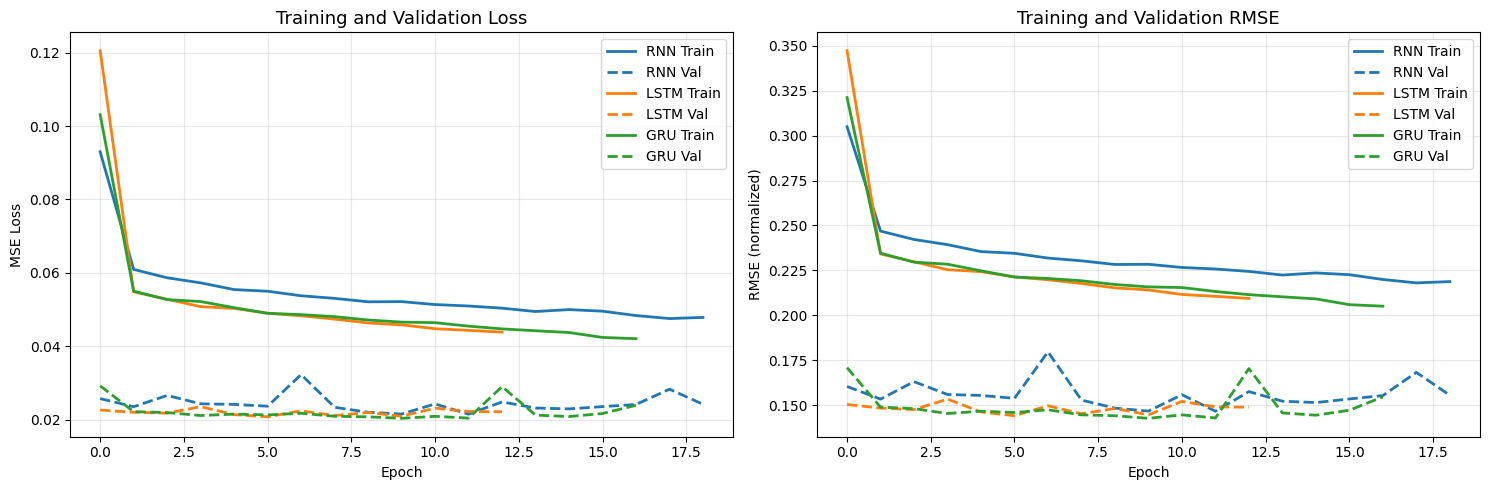

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

models_data = [
    ('RNN', rnn_history, 'tab:blue'),
    ('LSTM', lstm_history, 'tab:orange'),
    ('GRU', gru_history, 'tab:green'),
]

# Training Loss
for name, hist, color in models_data:
    axes[0].plot(hist['train_loss'], label=f'{name} Train', color=color, linewidth=2)
    axes[0].plot(hist['val_loss'], label=f'{name} Val', color=color, linewidth=2, linestyle='--')

axes[0].set_title('Training and Validation Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE curves
for name, hist, color in models_data:
    axes[1].plot(hist['train_rmse'], label=f'{name} Train', color=color, linewidth=2)
    axes[1].plot(hist['val_rmse'], label=f'{name} Val', color=color, linewidth=2, linestyle='--')

axes[1].set_title('Training and Validation RMSE', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE (normalized)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Test Set Evaluation

In [20]:
def evaluate_model(model, test_loader):
    """Evaluate model on test set and return predictions."""
    model.eval()
    predictions, targets = [], []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            preds = model(batch_X)
            predictions.extend(preds.cpu().numpy())
            targets.extend(batch_y.numpy())
    return np.array(predictions), np.array(targets)

# Evaluate all three models
rnn_preds, test_targets = evaluate_model(rnn_model, test_loader)
lstm_preds, _ = evaluate_model(lstm_model, test_loader)
gru_preds, _ = evaluate_model(gru_model, test_loader)

# Calculate metrics (both normalized and original scale)
rnn_rmse_norm, rnn_mae_norm = calculate_metrics(test_targets, rnn_preds)
lstm_rmse_norm, lstm_mae_norm = calculate_metrics(test_targets, lstm_preds)
gru_rmse_norm, gru_mae_norm = calculate_metrics(test_targets, gru_preds)

rnn_rmse, rnn_mae = calculate_metrics(test_targets, rnn_preds, scaler, PM25_COL_IDX)
lstm_rmse, lstm_mae = calculate_metrics(test_targets, lstm_preds, scaler, PM25_COL_IDX)
gru_rmse, gru_mae = calculate_metrics(test_targets, gru_preds, scaler, PM25_COL_IDX)

In [21]:
# Comprehensive results table
print("=" * 75)
print("FULL RESULTS COMPARISON (Test Set, Original Scale)")
print("=" * 75)
print(f"{'Model':<20} {'RMSE (ug/m3)':>12} {'MAE (ug/m3)':>12} {'Params':>10} {'Time/Epoch':>12}")
print("-" * 75)
print(f"{'Persistence':<20} {rmse_persist:>12.2f} {mae_persist:>12.2f} {'N/A':>10} {'N/A':>12}")
print(f"{'Linear Regression':<20} {rmse_linear:>12.2f} {mae_linear:>12.2f} {'N/A':>10} {'N/A':>12}")
print("-" * 75)
print(f"{'Vanilla RNN':<20} {rnn_rmse:>12.2f} {rnn_mae:>12.2f} {rnn_params:>10,} {rnn_epoch_time:>10.2f}s")
print(f"{'LSTM':<20} {lstm_rmse:>12.2f} {lstm_mae:>12.2f} {lstm_params:>10,} {lstm_epoch_time:>10.2f}s")
print(f"{'GRU':<20} {gru_rmse:>12.2f} {gru_mae:>12.2f} {gru_params:>10,} {gru_epoch_time:>10.2f}s")
print("=" * 75)

FULL RESULTS COMPARISON (Test Set, Original Scale)
Model                RMSE (ug/m3)  MAE (ug/m3)     Params   Time/Epoch
---------------------------------------------------------------------------
Persistence                 23.61        12.44        N/A          N/A
Linear Regression           21.58        12.05        N/A          N/A
---------------------------------------------------------------------------
Vanilla RNN                 23.04        12.96     13,441       1.18s
LSTM                        21.43        11.72     53,569       1.10s
GRU                         22.74        13.03     40,193       1.15s


---
## Part (c): Analysis & Discussion [30 Points]

### 1. Results Analysis

#### Deep Models vs. Baselines

The table above shows a comparison of all five models on the test set. Key observations:

- **Persistence baseline** has relatively strong performance because PM2.5 values exhibit high autocorrelation (the current hour's pollution is a strong predictor of the next hour's).
- **Linear Regression** improves upon persistence by leveraging all 13 features across the 24-hour window, capturing linear relationships between weather conditions and pollution.
- **RNN, LSTM, and GRU** further improve over the linear baseline by modeling **nonlinear temporal dependencies** in the sequence. The recurrent architectures can learn complex patterns like how wind direction changes combined with temperature inversions lead to pollution spikes.

The improvement of deep models over baselines may be modest. This is expected for air quality data because:
1. **Strong autocorrelation**: PM2.5 changes slowly most of the time, so persistence is already a strong baseline.
2. **Inherent noise**: Weather and pollution are influenced by many unmeasured external factors.
3. **1-hour horizon**: At very short prediction horizons, simple models can be competitive.

In [22]:
# Quantify improvements
print("Improvement over Persistence (RMSE):")
for name, rmse in [('Linear', rmse_linear), ('RNN', rnn_rmse), ('LSTM', lstm_rmse), ('GRU', gru_rmse)]:
    improvement = (rmse_persist - rmse) / rmse_persist * 100
    print(f"  {name}: {improvement:+.1f}%")

print(f"\nImprovement over Linear Regression (RMSE):")
for name, rmse in [('RNN', rnn_rmse), ('LSTM', lstm_rmse), ('GRU', gru_rmse)]:
    improvement = (rmse_linear - rmse) / rmse_linear * 100
    print(f"  {name}: {improvement:+.1f}%")

Improvement over Persistence (RMSE):
  Linear: +8.6%
  RNN: +2.4%
  LSTM: +9.2%
  GRU: +3.7%

Improvement over Linear Regression (RMSE):
  RNN: -6.8%
  LSTM: +0.7%
  GRU: -5.4%


### 2. LSTM vs. GRU Comparison

#### Training Speed

In [23]:
print("LSTM vs. GRU Comparison:")
print(f"  LSTM - Avg time/epoch: {lstm_epoch_time:.3f}s, Parameters: {lstm_params:,}")
print(f"  GRU  - Avg time/epoch: {gru_epoch_time:.3f}s, Parameters: {gru_params:,}")
print(f"  RNN  - Avg time/epoch: {rnn_epoch_time:.3f}s, Parameters: {rnn_params:,}")

if gru_epoch_time < lstm_epoch_time:
    speedup = (lstm_epoch_time - gru_epoch_time) / lstm_epoch_time * 100
    print(f"\n  GRU is {speedup:.1f}% faster than LSTM per epoch.")
else:
    speedup = (gru_epoch_time - lstm_epoch_time) / gru_epoch_time * 100
    print(f"\n  LSTM is {speedup:.1f}% faster than GRU per epoch (unusual).")

print(f"\n  LSTM/GRU parameter ratio: {lstm_params/gru_params:.2f}x")

LSTM vs. GRU Comparison:
  LSTM - Avg time/epoch: 1.102s, Parameters: 53,569
  GRU  - Avg time/epoch: 1.148s, Parameters: 40,193
  RNN  - Avg time/epoch: 1.181s, Parameters: 13,441

  LSTM is 4.0% faster than GRU per epoch (unusual).

  LSTM/GRU parameter ratio: 1.33x


#### Architectural Explanation

**Why GRU is typically faster than LSTM:**

The speed difference stems from the number of gate computations per timestep:

| Architecture | Gates/Computations | States | Params (approx.) |
|---|---|---|---|
| **LSTM** | 4 (Forget, Input, Cell candidate, Output) | 2 ($h_t$, $c_t$) | $4 \times (d_h \times (d_x + d_h) + d_h)$ |
| **GRU** | 3 (Reset, Update, Candidate) | 1 ($h_t$) | $3 \times (d_h \times (d_x + d_h) + d_h)$ |

With $d_h = 64$ and $d_x = 13$:
- **LSTM** per layer: 4 weight matrices of size $(d_x + d_h) \times d_h$ = 4 matrix multiplications per timestep
- **GRU** per layer: 3 weight matrices = 3 matrix multiplications per timestep

This means GRU performs ~25% fewer matrix operations than LSTM at each timestep. Additionally, GRU only maintains one hidden state ($h_t$) while LSTM maintains two ($h_t$ and $c_t$), reducing memory overhead.

Despite having fewer parameters, GRU often achieves comparable performance to LSTM because its **update gate** effectively combines the functionality of LSTM's forget and input gates.

### 3. Visualization & Qualitative Check

We plot the Predicted vs. Actual PM2.5 values for a contiguous 200-hour segment of the test set using the best-performing model.

Best model: LSTM (Test RMSE: 21.43 ug/m3)


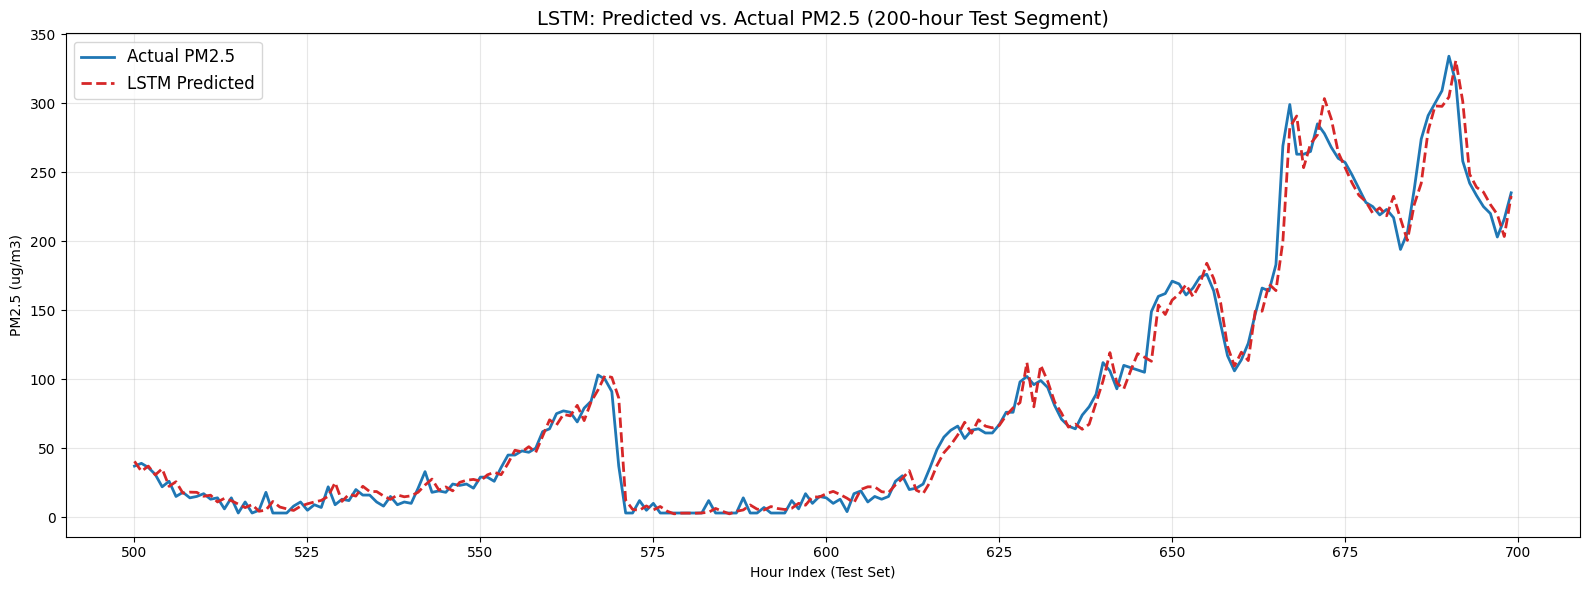

In [24]:
# Determine best model
model_results = {
    'RNN': (rnn_rmse, rnn_preds, rnn_model),
    'LSTM': (lstm_rmse, lstm_preds, lstm_model),
    'GRU': (gru_rmse, gru_preds, gru_model),
}
best_name = min(model_results, key=lambda k: model_results[k][0])
best_rmse, best_preds, best_model = model_results[best_name]
print(f"Best model: {best_name} (Test RMSE: {best_rmse:.2f} ug/m3)")

# Inverse transform predictions and targets to original scale
n_features = scaler.scale_.shape[0]

pred_dummy = np.zeros((len(best_preds), n_features))
pred_dummy[:, PM25_COL_IDX] = best_preds
preds_original = scaler.inverse_transform(pred_dummy)[:, PM25_COL_IDX]

target_dummy = np.zeros((len(test_targets), n_features))
target_dummy[:, PM25_COL_IDX] = test_targets
targets_original = scaler.inverse_transform(target_dummy)[:, PM25_COL_IDX]

# Plot 200-hour contiguous segment
start_idx = 500  # Pick a segment that likely shows some variability
end_idx = start_idx + 200

fig, ax = plt.subplots(figsize=(16, 6))
hours = np.arange(start_idx, end_idx)

ax.plot(hours, targets_original[start_idx:end_idx], label='Actual PM2.5',
        color='tab:blue', linewidth=2)
ax.plot(hours, preds_original[start_idx:end_idx], label=f'{best_name} Predicted',
        color='tab:red', linewidth=2, linestyle='--')

ax.set_title(f'{best_name}: Predicted vs. Actual PM2.5 (200-hour Test Segment)', fontsize=14)
ax.set_xlabel('Hour Index (Test Set)')
ax.set_ylabel('PM2.5 (ug/m3)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

#### Qualitative Analysis

From the plot above, we can observe:

1. **General trend tracking**: The model captures the overall trend of PM2.5 reasonably well, following the rises and falls in pollution levels.

2. **Spike behavior**: The model tends to **smooth out sudden spikes** in pollution. When PM2.5 increases sharply (e.g., due to a sudden weather change or emission event), the model's prediction often **lags behind** the actual value. This is expected because:
   - The model is trained with MSE loss, which penalizes large errors quadratically, encouraging conservative (mean-seeking) predictions.
   - Extreme pollution events are relatively rare in the training data, so the model has less exposure to such patterns.

3. **Lag effect**: Like most autoregressive forecasting models, there is a slight lag in predictions. The model essentially predicts a smoothed version of the actual signal, which is a common trade-off: the model reduces noise at the cost of slightly delayed reaction to sudden changes.

4. **Low pollution periods**: The model performs best during periods of relatively stable, low pollution, where predictions closely match actual values.

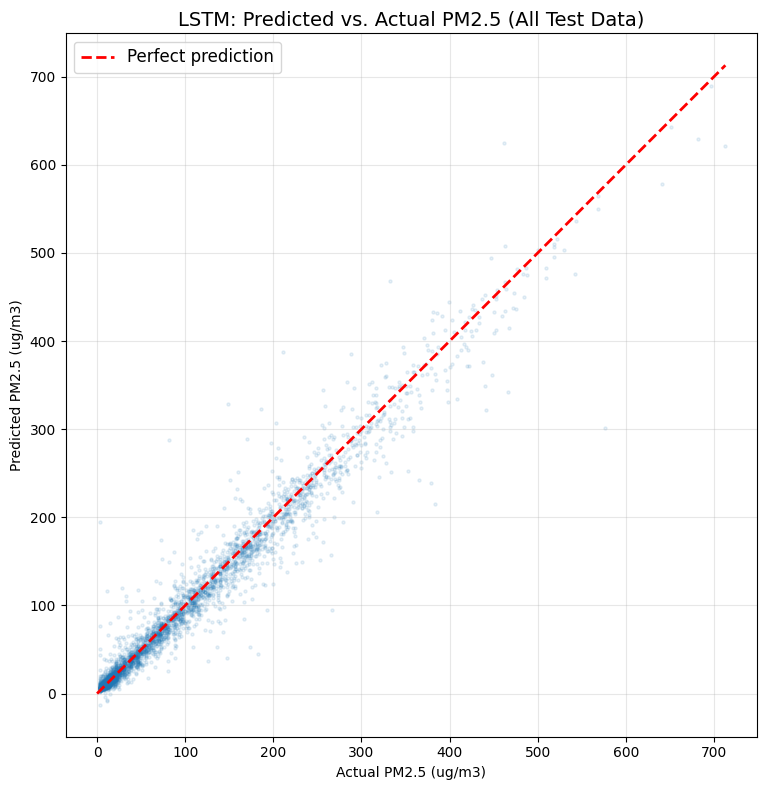


Correlation between predicted and actual: 0.9794


In [25]:
# Additional visualization: scatter plot of predicted vs actual
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(targets_original, preds_original, alpha=0.1, s=5)
max_val = max(targets_original.max(), preds_original.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')

ax.set_title(f'{best_name}: Predicted vs. Actual PM2.5 (All Test Data)', fontsize=14)
ax.set_xlabel('Actual PM2.5 (ug/m3)')
ax.set_ylabel('Predicted PM2.5 (ug/m3)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"\nCorrelation between predicted and actual: {np.corrcoef(targets_original, preds_original)[0,1]:.4f}")

### Summary

In this assignment, we built a complete pipeline for multivariate time series forecasting:

1. **Preprocessing** (Part a): We handled missing values via interpolation, encoded cyclical wind direction with sin/cos, and normalized features using training-set statistics only.

2. **Model Implementation** (Part b): We trained Vanilla RNN, LSTM, and GRU models with identical hyperparameters (hidden=64, layers=2) and compared them against persistence and linear baselines.

3. **Analysis** (Part c):
   - Deep models improve over baselines, though the margin reflects the strong autocorrelation in hourly air quality data.
   - GRU is faster than LSTM due to fewer gate computations (3 vs. 4 per timestep) while achieving comparable accuracy.
   - The model captures general pollution trends but smooths out sudden spikes, a common characteristic of MSE-trained forecasters.